#### Setup & Import

In [15]:
#!pip install datasets
#!pip install torch
#!pip install torch torchvision torchaudio

In [153]:
import os, glob
checkpoints = sorted(glob.glob("checkpoints/*.pt"), key=os.path.getmtime)
for old_ckpt in checkpoints[:-5]:  # 保留最新5个
    os.remove(old_ckpt)

In [1]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
import pandas as pd
import torchvision.models as models
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import random

from datasets import load_dataset
from pandas import crosstab
from torchvision import transforms
from torch.utils.data import DataLoader
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import accuracy_score

C:\Users\beryl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


#### Load Data

In [5]:
# load food101 dataset
from datasets import load_dataset
ds = load_dataset("ethz/food101")

In [6]:
ds['train'].select(range(5))

Dataset({
    features: ['image', 'label'],
    num_rows: 5
})

#### Transform

In [7]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [8]:
# preprocess the bytes to tensor
def preprocess(ex):
    return {
        "pixel_values": transform(ex["image"].convert("RGB")),
        "label": ex["label"]
    }

train_ds = ds["train"].map(preprocess, remove_columns=["image"])
test_ds  = ds["validation"].map (preprocess, remove_columns=["image"])

Map:  40%|███▉      | 30069/75750 [02:35<10:54, 69.81 examples/s] C:\Users\beryl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
Map: 100%|██████████| 25250/25250 [02:14<00:00, 187.76 examples/s]


In [9]:
# subset with 100 image per class for the training set
labels = train_ds["label"]
df_labels = pd.DataFrame({"label": labels})

df_sampled = (
    df_labels
    .groupby("label", group_keys=False)
    .sample(n=100, random_state=20250520)
)

sampled_idx = df_sampled.index.tolist()
sampled_train = train_ds.select(sampled_idx)
print(sampled_train)


Dataset({
    features: ['label', 'pixel_values'],
    num_rows: 10100
})


In [ ]:
# subset with 100 image per class for the test set
labels = test_ds["label"]
df_labels = pd.DataFrame({"label": labels})

df_sampled = (
    df_labels
    .groupby("label", group_keys=False)
    .sample(n=100, random_state=20250520)
)

sampled_idx = df_sampled.index.tolist()
sampled_test = test_ds.select(sampled_idx)
print(sampled_test)

Dataset({
    features: ['label', 'pixel_values'],
    num_rows: 10100
})


In [11]:
#convert to torch format
sampled_train.set_format(type="torch", columns=["pixel_values", "label"])
sampled_test .set_format(type="torch", columns=["pixel_values", "label"])

## Three Subclasses Training

In [12]:
# map to classes
appetizer_idx = {5, 6, 10, 11, 13, 15, 17, 30, 32, 33, 35, 36, 43, 46, 52, 54, 57, 64, 65, 66, 68, 69, 85, 86, 87, 88, 92}
main_course_idx = {1, 3, 4, 7, 9, 18, 19, 20, 24, 25, 26, 28, 32, 34, 37, 38, 39, 41, 49, 50, 53, 55, 56, 59, 60, 61, 62, 67, 70, 71, 74, 75, 76, 77, 78, 79, 80, 81, 82, 84, 90, 91, 93, 95, 96, 97, 99}
dessert_idx = {0, 2, 8, 12, 14, 16, 21, 22, 23, 27, 29, 31, 45, 58, 63, 73, 83, 94, 98, 100}

In [13]:
def map_to_food_type(index):
    if index in appetizer_idx:
        return 0  # Appetizer
    elif index in main_course_idx:
        return 1  # Main Course
    elif index in dessert_idx:
        return 2  # Dessert
    else:
        return 3  # Other

train_subclass = sampled_train.map(lambda x: {"label": map_to_food_type(int(x["label"]))})
test_subclass = sampled_test.map(lambda x: {"label": map_to_food_type(int(x["label"]))})

train_subclass = train_subclass.filter(lambda x: x["label"] != 3)
test_subclass  = test_subclass .filter(lambda x: x["label"] != 3)

Filter: 100%|██████████| 10100/10100 [01:05<00:00, 153.08 examples/s]


In [14]:
from collections import Counter
cnt = Counter(int(x) for x in train_subclass["label"])
print(cnt)

Counter({1: 4600, 0: 2700, 2: 2000})


In [15]:
for ds in (train_subclass, test_subclass):
    ds.set_format("torch", columns=["pixel_values","label"])

In [16]:
# Create a wrapper class
class FoodDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        return item["pixel_values"], item["label"]

In [17]:
train_loader = DataLoader(train_subclass, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_subclass, batch_size=32, shuffle=True, num_workers=0)

#### Load Pretrained EfficientNet (B0)

In [18]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# Replace classifier head
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 3)
model = model.to(device)

####  Define Loss and Optimizer

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

#### Training Loop

In [20]:
from tqdm import tqdm

def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in tqdm(dataloader, desc="Training"):
        images = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)

#### Validation Loop

In [21]:
def evaluate(model, dataloader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for batch in dataloader:
            images = batch["pixel_values"].to(device)
            labels = batch["label"].to(device)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

#### First Stage

In [22]:
# training set
import time

best_val_train = 0
num_epochs = 6

acc_train = []
for epoch in range(num_epochs):
    start = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_acc    = evaluate   (model, train_loader)
    acc_train.append(val_acc)

    if val_acc > best_val_train:
        best_val_train = val_acc


    print(f"Epoch {epoch+1}: Loss={train_loss:.4f}, "
          f"Val Acc={val_acc:.2%}, Time={time.time()-start:.2f}s")

Training: 100%|██████████| 291/291 [05:30<00:00,  1.13s/it]


Epoch 1: Loss=0.8131, Val Acc=80.30%, Time=454.75s


Training: 100%|██████████| 291/291 [05:28<00:00,  1.13s/it]


Epoch 2: Loss=0.5619, Val Acc=90.70%, Time=451.58s


Training: 100%|██████████| 291/291 [05:28<00:00,  1.13s/it]


...

Epoch 4: Loss=0.2411, Val Acc=98.81%, Time=451.79s


Training: 100%|██████████| 291/291 [05:28<00:00,  1.13s/it]


Epoch 5: Loss=0.1528, Val Acc=99.67%, Time=451.25s


Training: 100%|██████████| 291/291 [05:27<00:00,  1.13s/it]


Epoch 6: Loss=0.1240, Val Acc=99.87%, Time=450.60s


In [23]:
import time

best_val = 0
num_epochs = 6

acc = []
for epoch in range(num_epochs):
    start = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_acc    = evaluate   (model, test_loader)
    acc.append(val_acc)

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), "best_model.pt")

    torch.save({
    "epoch":                epoch,
    "model_state_dict":     model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_val_acc":         best_val
}, "checkpoint.pth")

    print(f"Epoch {epoch+1}: Loss={train_loss:.4f}, "
          f"Val Acc={val_acc:.2%}, Time={time.time()-start:.2f}s")

Training: 100%|██████████| 291/291 [05:27<00:00,  1.12s/it]


Epoch 1: Loss=0.1032, Val Acc=76.24%, Time=444.96s


Training: 100%|██████████| 291/291 [05:27<00:00,  1.12s/it]


Epoch 2: Loss=0.0884, Val Acc=76.85%, Time=444.55s


Training: 100%|██████████| 291/291 [05:27<00:00,  1.13s/it]


...

Epoch 4: Loss=0.0566, Val Acc=77.46%, Time=449.90s


Training: 100%|██████████| 291/291 [05:55<00:00,  1.22s/it]


Epoch 5: Loss=0.0679, Val Acc=76.65%, Time=483.64s


Training: 100%|██████████| 291/291 [05:55<00:00,  1.22s/it]


Epoch 6: Loss=0.0565, Val Acc=77.73%, Time=483.29s


In [24]:
def get_confusion_matrix(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Building confusion matrix"):
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['label'].to(device)
            preds = model(pixel_values).argmax(dim=1)
            all_preds .extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    df_cm = pd.crosstab(
        pd.Series(all_labels, name="Actual"),
        pd.Series(all_preds,  name="Predicted"),
        rownames=["Actual"], colnames=["Predicted"]
    )
    return df_cm

cm = get_confusion_matrix(model, train_loader, device)
print(cm)

Building confusion matrix: 100%|██████████| 291/291 [02:15<00:00,  2.15it/s]

Predicted     0     1     2
Actual                     
0          2700     0     0
1             0  4600     0
2             0     0  2000


In [47]:
# ckpt = torch.load("checkpoint.pth", map_location=device)
#
# model = models.efficientnet_b0(weights=None)
# model.classifier[1] = nn.Linear(model.classifier[1].in_features, 4)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
#
# # restore the last checkpoint
# model.load_state_dict(ckpt["model_state_dict"])
# optimizer.load_state_dict(ckpt["optimizer_state_dict"])
# start_epoch = ckpt["epoch"] + 1
# best_val    = ckpt["best_val_acc"]
#
# model.to(device)
#
# # start from the last check point
# extra_epochs = 10
# for epoch in range(start_epoch, start_epoch + extra_epochs):
#     train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
#     val_acc  = evaluate(model, test_loader)
#     acc.append(val_acc)
#
#     if val_acc > best_val:
#         best_val = val_acc
#         torch.save(model.state_dict(), "best_model.pt")
#
#     torch.save({
#     "epoch":                epoch,
#     "model_state_dict":     model.state_dict(),
#     "optimizer_state_dict": optimizer.state_dict(),
#     "best_val_acc":         best_val
# }, "checkpoint.pth")
#
#     print(f"Epoch {epoch+1} — Loss {train_loss:.4f}  Val Acc {val_acc:.2%}")

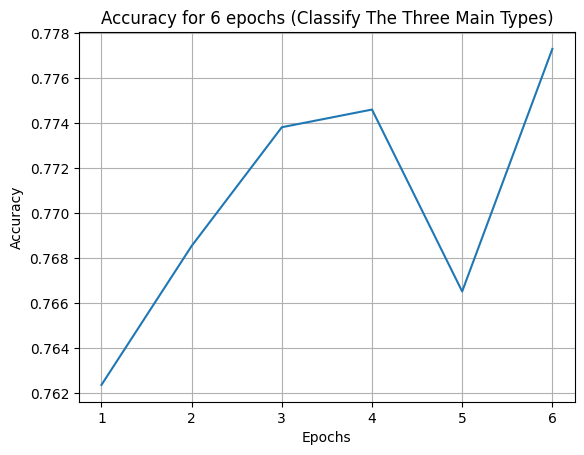

In [25]:
epochs = list(range(1,7))

# plot of accuracy
plt.figure()
plt.plot(epochs, acc)
plt.xticks(epochs)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy for 6 epochs (Classify The Three Main Types)")
plt.grid(True)
plt.show()

## Appetizer/ Main Course/ Dessert Subclass Training

In [26]:
# divide dataset by subclasses
def make_class (subclass_index, dataset):
    labels = dataset["label"]
    df_labels = pd.DataFrame({"label": labels})
    df_app = df_labels[df_labels["label"].isin(subclass_index)]

    indices = df_app.index.tolist()
    subclass_ds = dataset.select(indices)
    return subclass_ds

# save the subclasses dataset
app_train_sample = make_class(appetizer_idx, sampled_train)
app_test_sample = make_class(appetizer_idx, sampled_test)
main_train_sample = make_class(main_course_idx, sampled_train)
main_test_sample = make_class(main_course_idx, sampled_test)
des_train_sample = make_class(dessert_idx, sampled_train)
des_test_sample = make_class(dessert_idx, sampled_test)

In [27]:
# change the class number to start from 0
def build_label_map(idx_set):
    sorted_orig = sorted(idx_set)
    return {orig: new for new, orig in enumerate(sorted_orig)}

app_map   = build_label_map(appetizer_idx)
main_map  = build_label_map(main_course_idx)
dess_map  = build_label_map(dessert_idx)

# map each existing class label to new label
app_train_sample = app_train_sample.map(lambda ex: {"label": app_map[ex["label"].item()]})
app_test_sample  = app_test_sample .map(lambda ex: {"label": app_map[ex["label"].item()]})

main_train_sample = main_train_sample.map(lambda ex: {"label": main_map[ex["label"].item()]})
main_test_sample  = main_test_sample .map(lambda ex: {"label": main_map[ex["label"].item()]})

des_train_sample = des_train_sample.map(lambda ex: {"label": dess_map[ex["label"].item()]})
des_test_sample  = des_test_sample .map(lambda ex: {"label": dess_map[ex["label"].item()]})

# change to tensor format
for ds in [app_train_sample, app_test_sample,
           main_train_sample, main_test_sample,
           des_train_sample, des_test_sample]:
    ds.set_format("torch", columns=["pixel_values", "label"])

Map: 100%|██████████| 2000/2000 [00:15<00:00, 126.89 examples/s]


In [28]:
# subclass training pipeline
def train_subtask(
    name,                   # 'appetizer' / 'main_course' / 'dessert'
    train_ds,
    val_ds,
    num_classes,            # num of classes in the subclass
    epochs=10,
):
    print(f"\n=== Training subtask [{name}] ({num_classes} classes) ===")
    # a) dataloader
    train_loader = DataLoader(train_ds,
                              batch_size=32,
                              shuffle=True,
                              num_workers=0)
    val_loader   = DataLoader(val_ds,
                              batch_size=32,
                              shuffle=False,
                              num_workers=0)
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    best_path = f"best_{name}.pt"

    epoch_acc = []

    for ep in range(1, epochs+1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_acc_train  = evaluate(model, train_loader)
        val_acc_test    = evaluate(model, val_loader)
        epoch_acc.append(val_acc_test)
        print(f"Epoch {ep:02d}  train_loss={train_loss:.4f}"
              f"  train_acc = {val_acc_train} test_acc={val_acc_test:.2%}")
        # save the best model
        if val_acc_test > best_acc:
            best_acc = val_acc_test
            torch.save(model.state_dict(), best_path)
    print(f"Subtask [{name}] best val acc: {best_acc:.2%}, checkpoint saved to {best_path}")
    return model, best_path, epoch_acc


In [29]:
model_app, app_best_path, app_epoch_acc = train_subtask('appetizer', app_train_sample, app_test_sample, num_classes=len(appetizer_idx))


=== Training subtask [appetizer] (27 classes) ===


Training: 100%|██████████| 85/85 [01:48<00:00,  1.28s/it]


Epoch 01  train_loss=3.0907  train_acc = 0.5411111111111111 test_acc=36.44%


Training: 100%|██████████| 85/85 [01:43<00:00,  1.22s/it]


Epoch 02  train_loss=2.2029  train_acc = 0.7092592592592593 test_acc=54.67%


...

Epoch 08  train_loss=0.2439  train_acc = 0.9948148148148148 test_acc=72.15%


Training: 100%|██████████| 85/85 [01:42<00:00,  1.20s/it]


Epoch 09  train_loss=0.1838  train_acc = 0.9966666666666667 test_acc=72.78%


Training: 100%|██████████| 85/85 [01:42<00:00,  1.20s/it]


Epoch 10  train_loss=0.1393  train_acc = 0.9981481481481481 test_acc=72.19%
Subtask [appetizer] best val acc: 73.07%, checkpoint saved to best_appetizer.pt


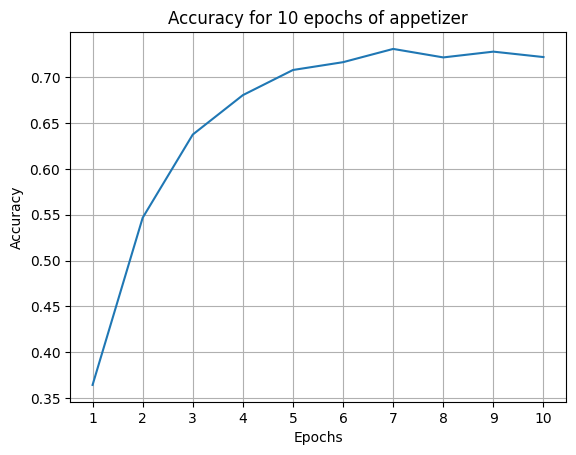

In [30]:
epochs = list(range(1,11))

# accuracy plot for the dessert group
plt.figure()
plt.plot(epochs, app_epoch_acc)
plt.xticks(epochs)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy for 10 epochs of appetizer")
plt.grid(True)
plt.show()

In [31]:
model_main, main_best_path, main_epoch_acc = train_subtask('main_course', main_train_sample, main_test_sample, num_classes=len(main_course_idx))


=== Training subtask [main_course] (47 classes) ===


Training: 100%|██████████| 147/147 [03:04<00:00,  1.25s/it]


Epoch 01  train_loss=3.5762  train_acc = 0.41382978723404257 test_acc=36.31%


Training: 100%|██████████| 147/147 [02:46<00:00,  1.13s/it]


Epoch 02  train_loss=2.6089  train_acc = 0.5768085106382979 test_acc=50.71%


...

Epoch 08  train_loss=0.4091  train_acc = 0.9887234042553191 test_acc=61.83%


Training: 100%|██████████| 147/147 [02:43<00:00,  1.12s/it]


Epoch 09  train_loss=0.3158  train_acc = 0.9961702127659574 test_acc=62.62%


Training: 100%|██████████| 147/147 [02:44<00:00,  1.12s/it]


Epoch 10  train_loss=0.2335  train_acc = 0.9976595744680851 test_acc=62.10%
Subtask [main_course] best val acc: 62.62%, checkpoint saved to best_main_course.pt


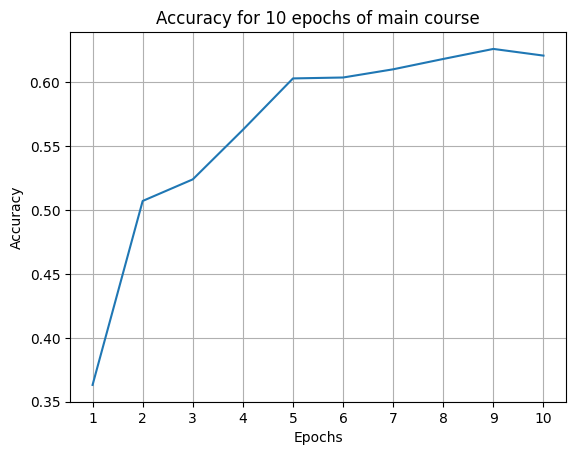

In [32]:
epochs = list(range(1,11))

# accuracy plot for the dessert group
plt.figure()
plt.plot(epochs, main_epoch_acc)
plt.xticks(epochs)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy for 10 epochs of main course")
plt.grid(True)
plt.show()

In [33]:
model_des, des_best_path, des_epoch_acc = train_subtask('dessert', des_train_sample, des_test_sample, num_classes=len(dessert_idx))


=== Training subtask [dessert] (20 classes) ===


Training: 100%|██████████| 63/63 [01:19<00:00,  1.26s/it]


Epoch 01  train_loss=2.9001  train_acc = 0.463 test_acc=17.75%


Training: 100%|██████████| 63/63 [01:15<00:00,  1.20s/it]


Epoch 02  train_loss=2.3659  train_acc = 0.651 test_acc=24.85%


...

Epoch 08  train_loss=0.3332  train_acc = 0.996 test_acc=54.45%


Training: 100%|██████████| 63/63 [01:15<00:00,  1.20s/it]


Epoch 09  train_loss=0.2443  train_acc = 0.9985 test_acc=56.20%


Training: 100%|██████████| 63/63 [01:15<00:00,  1.20s/it]


Epoch 10  train_loss=0.1775  train_acc = 0.9985 test_acc=55.00%
Subtask [dessert] best val acc: 56.20%, checkpoint saved to best_dessert.pt


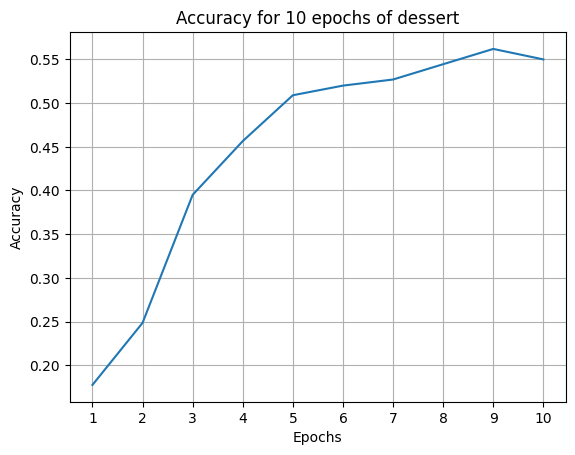

In [34]:
epochs = list(range(1,11))

# accuracy plot for the dessert group
plt.figure()
plt.plot(epochs, des_epoch_acc)
plt.xticks(epochs)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy for 10 epochs of dessert")
plt.grid(True)
plt.show()

In [35]:
class RouterNet(nn.Module):
    def __init__(self):
        super().__init__()
        weights = EfficientNet_B0_Weights.DEFAULT
        self.net = efficientnet_b0(weights=weights)
        # replace head for 3 super-classes
        in_f = self.net.classifier[1].in_features
        self.net.classifier[1] = nn.Linear(in_f, 3)
    def forward(self, x):
        return self.net(x)

In [36]:
def build_specialist(num_labels, checkpoint_path):
    weights = EfficientNet_B0_Weights.DEFAULT
    m = efficientnet_b0(weights=weights)
    in_f = m.classifier[1].in_features
    m.classifier[1] = nn.Linear(in_f, num_labels)
    m.load_state_dict(torch.load(checkpoint_path, map_location=device))
    m.eval()
    m.to(device)
    return m

In [37]:
def make_maps(idx_set):
    sorted_list = sorted(idx_set)
    global2local = {g:i for i,g in enumerate(sorted_list)}
    local2global = {i:g for i,g in enumerate(sorted_list)}
    return global2local, local2global

In [38]:
app_g2l, app_l2g   = make_maps(appetizer_idx)
main_g2l, main_l2g = make_maps(main_course_idx)
des_g2l, des_l2g   = make_maps(dessert_idx)

In [39]:
router   = RouterNet().to(device)
state = torch.load('best_model.pt')
router.net.load_state_dict(state)

<All keys matched successfully>

In [40]:
app_net  = build_specialist(len(appetizer_idx),   "best_appetizer.pt")
main_net = build_specialist(len(main_course_idx), "best_main_course.pt")
des_net  = build_specialist(len(dessert_idx),     "best_dessert.pt")

In [41]:
def run_combined(dataloader):
    y_true, y_pred = [], []
    correct, total = 0, 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            imgs  = batch['pixel_values'].to(device)
            labs  = batch['label'].to(device)
            # stage 1
            logits1 = router(imgs)
            which   = logits1.argmax(dim=1)   # in {0,1,2}
            for i in range(imgs.size(0)):
                x = imgs[i].unsqueeze(0)
                gt = labs[i].item()
                # route to correct specialist
                if which[i]==0:       # appetizer
                    out = app_net(x).argmax(dim=1).item()
                    pred = app_l2g[out]
                elif which[i]==1:     # main
                    out = main_net(x).argmax(dim=1).item()
                    pred = main_l2g[out]
                else:                 # dessert
                    out = des_net(x).argmax(dim=1).item()
                    pred = des_l2g[out]
                y_true.append(gt)
                y_pred.append(pred)

                total +=1
                correct += int(pred == gt)
    return y_true, y_pred, correct, total

In [42]:
def confusion_matrix(y_true, y_pred, n_classes):
    df = pd.crosstab(
        pd.Series(y_true, name="Actual"),
        pd.Series(y_pred, name="Predicted"),
        rownames=["Actual"], colnames=["Predicted"]
    )
    for i in range(n_classes):
        if i not in df.index:   df.loc[i] = 0
        if i not in df.columns: df[i] = 0
    df = df.sort_index(axis=0).sort_index(axis=1)
    return df

In [43]:
# build fall class train and test loader
full_train_loader = DataLoader(sampled_train,
                               batch_size=32,
                               shuffle=False,
                               num_workers=0)
full_test_loader = DataLoader(sampled_test,
                               batch_size=32,
                               shuffle=False,
                               num_workers=0)

In [44]:
router.eval()
app_net.eval()
main_net.eval()
des_net.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [45]:
y_t, y_p, correct, total = run_combined(full_train_loader)
cm_train = confusion_matrix(y_t, y_p, n_classes=101)
accuracy_score_train = correct/total
print(f'Combined accuracy for the training set: {accuracy_score_train:.2%}')

Evaluating: 100%|██████████| 316/316 [07:37<00:00,  1.45s/it]

Combined accuracy for the training set: 91.46%


In [46]:
from collections import Counter

y_true, y_pred, _, _ = run_combined(full_test_loader)
counts = Counter(y_true)
print(counts.most_common())  # shows (class, #samples)


Evaluating: 100%|██████████| 316/316 [07:33<00:00,  1.44s/it]

[(20, 300), (72, 300), (34, 300), (5, 300), (0, 300), (48, 300), (6, 300), (22, 300), (93, 300), (64, 300), (79, 300), (84, 300), (70, 300), (11, 300), (77, 300), (59, 300), (46, 300), (38, 300), (73, 300), (10, 300), (76, 300), (44, 300), (43, 300), (98, 300), (55, 300), (53, 300), (86, 300), (51, 300), (14, 300), (57, 300), (21, 300), (99, 300), (81, 300), (16, 200)]


In [47]:
pd.set_option('display.max_rows',    101)
pd.set_option('display.max_columns', 101)
print(cm_train)

cm_train.to_csv("confusion_matrix_train.csv", index=True)

Predicted  0    1    2    3    4    5    6    7    8    9    10   11   12   \
Actual                                                                       
0          100    0    0    0    0    0    0    0    0    0    0    0    0   
1            0  100    0    0    0    0    0    0    0    0    0    0    0   
2            0    0  100    0    0    0    0    0    0    0    0    0    0   
3            0    0    0  100    0    0    0    0    0    0    0    0    0   
4            0    0    0    0  100    0    0    0    0    0    0    0    0   
5            0    0    0    0    0   94    0    0    0    0    0    4    0   
6            0    0    0    0    0    0  100    0    0    0    0    0    0   
7            0    0    0    0    0    0    0  100    0    0    0    0    0   
8            0    0    0    0    0    0    0    0  100    0    0    0    0   
9            0    0    0    0    0    0    0    0    0  100    0    0    0   
10           0    0    0    0    0    0    0    0    0    0   97

In [48]:
print(total)
print(correct)

10100
9237


In [49]:
y_t_test, y_p_test, correct_test, total_test = run_combined(full_test_loader)
cm_test = confusion_matrix(y_t_test, y_p_test, n_classes=101)
accuracy_score_test = correct_test/total_test
print(f'Combined accuracy for the test set: {accuracy_score_test:.2%}')
print(cm_test)

Evaluating: 100%|██████████| 316/316 [06:41<00:00,  1.27s/it]

Combined accuracy for the test set: 46.37%
Predicted  0    1    2    3    4    5    6    7    8    9    10   11   12   \
Actual                                                                       
0           96    2   13    0    3    0    7    0   22    3    1    4    3   
1            0    0    0    0    0    0    0    0    0    0    0    0    0   
2            0    0    0    0    0    0    0    0    0    0    0    0    0   
3            0    0    0    0    0    0    0    0    0    0    0    0    0   
4            0    0    0    0    0    0    0    0    0    0    0    0    0   
5            1    2    0   23    5  123    1    2    0    0    4   14    0   
6            5    0    2    0    1    0  209    0    0    0    0    1    6   
7            0    0    0    0    0    0    0    0    0    0    0    0    0   
8            0    0    0    0    0    0    0    0    0    0    0    0    0   
9            0    0    0    0    0    0    0    0    0    0    0    0    0   
10           5    1  

In [50]:
cm_test.to_csv("confusion_matrix_test.csv", index=True)

## Sensitivity

Top-5 highest sens: [64, 70, 6, 76, 38]
Top-5 lowest  sens (used only): [10, 0, 93, 99, 57]


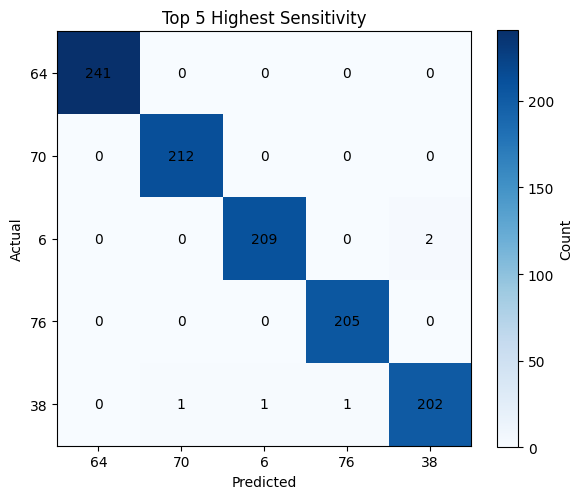

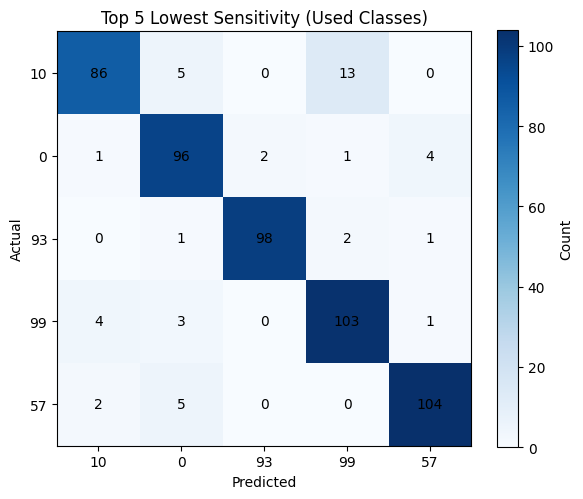

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# --- your three sets of used classes ---
appetizer_idx   = {5, 6, 10, 11, 13, 15, 17, 30, 32, 33, 35, 36, 43, 46, 52, 54, 57, 64, 65, 66, 68, 69, 85, 86, 87, 88, 92}
main_course_idx = {1, 3, 4, 7, 9, 18, 19, 20, 24, 25, 26, 28, 32, 34, 37, 38, 39, 41, 49, 50, 53, 55, 56, 59, 60, 61, 62, 67, 70, 71, 74, 75, 76, 77, 78, 79, 80, 81, 82, 84, 90, 91, 93, 95, 96, 97, 99}
dessert_idx     = {0, 2, 8, 12, 14, 16, 21, 22, 23, 27, 29, 31, 45, 58, 63, 73, 83, 94, 98, 100}

used_idx = appetizer_idx | main_course_idx | dessert_idx

# --- load & prepare your confusion matrix ---
cm = pd.read_csv('./confusion_matrix_test.csv', index_col=0)
cm.index = cm.index.astype(int)
cm.columns = cm.columns.astype(int)
cm = cm.sort_index().sort_index(axis=1)

# --- compute sensitivity per class ---
tp = pd.Series(cm.values.diagonal(), index=cm.index)
fn = cm.sum(axis=1) - tp
sensitivity = tp / (tp + fn)

# --- top 5 highest sensitivity (unchanged) ---
top5_classes = sensitivity.sort_values(ascending=False).head(5).index.tolist()

# --- bottom 5 among only the USED classes ---
bottom5_classes = (
    sensitivity[sensitivity.index.isin(used_idx)]
    .sort_values(ascending=True)
    .head(5)
    .index
    .tolist()
)

print("Top-5 highest sens:", top5_classes)
print("Top-5 lowest  sens (used only):", bottom5_classes)

# --- subset & plot as before (with cmap='Blues') ---
def plot_heatmap(subset_cm, title):
    plt.figure(figsize=(6,5))
    plt.imshow(subset_cm.values, cmap='Blues', interpolation='nearest')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar(label='Count')
    for i in range(subset_cm.shape[0]):
        for j in range(subset_cm.shape[1]):
            plt.text(j, i, subset_cm.iat[i, j], ha='center', va='center')
    labels = list(subset_cm.index)
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    plt.tight_layout()
    plt.show()

cm_top5    = cm.reindex(index=top5_classes,    columns=top5_classes,    fill_value=0)
cm_bottom5 = cm.reindex(index=bottom5_classes, columns=bottom5_classes, fill_value=0)

plot_heatmap(cm_top5,    "Top 5 Highest Sensitivity")
plot_heatmap(cm_bottom5, "Top 5 Lowest Sensitivity (Used Classes)")


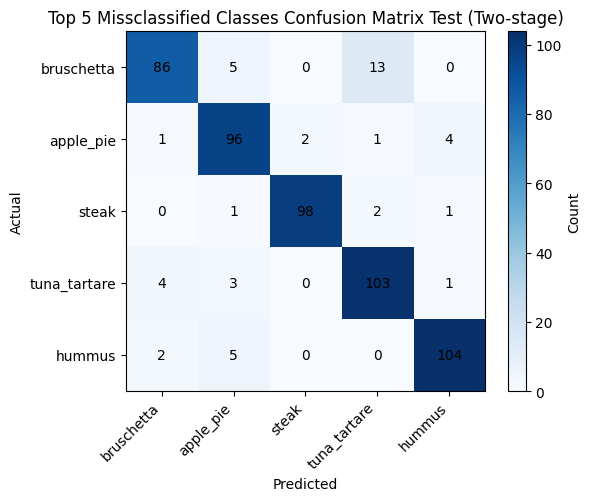

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define your used classes
appetizer_idx   = {5, 6, 10, 11, 13, 15, 17, 30, 32, 33, 35, 36, 43, 46, 52, 54, 57, 64, 65, 66, 68, 69, 85, 86, 87, 88, 92}
main_course_idx = {1, 3, 4, 7, 9, 18, 19, 20, 24, 25, 26, 28, 32, 34, 37, 38, 39, 41, 49, 50, 53, 55, 56, 59, 60, 61, 62, 67, 70, 71, 74, 75, 76, 77, 78, 79, 80, 81, 82, 84, 90, 91, 93, 95, 96, 97, 99}
dessert_idx     = {0, 2, 8, 12, 14, 16, 21, 22, 23, 27, 29, 31, 45, 58, 63, 73, 83, 94, 98, 100}
used_idx = appetizer_idx | main_course_idx | dessert_idx

# Load confusion matrix
cm = pd.read_csv('./confusion_matrix_test.csv', index_col=0).astype(int)
cm.index = cm.index.astype(int)
cm.columns = cm.columns.astype(int)

# Invert your class map
class_map = {
  "apple_pie": 0, "baby_back_ribs": 1, "baklava": 2, "beef_carpaccio": 3, "beef_tartare": 4,
  "beet_salad": 5, "beignets": 6, "bibimbap": 7, "bread_pudding": 8, "breakfast_burrito": 9,
  "bruschetta": 10, "caesar_salad": 11, "cannoli": 12, "caprese_salad": 13, "carrot_cake": 14,
  "ceviche": 15, "cheesecake": 16, "cheese_plate": 17, "chicken_curry": 18, "chicken_quesadilla": 19,
  "chicken_wings": 20, "chocolate_cake": 21, "chocolate_mousse": 22, "churros": 23, "clam_chowder": 24,
  "club_sandwich": 25, "crab_cakes": 26, "creme_brulee": 27, "croque_madame": 28, "cup_cakes": 29,
  "deviled_eggs": 30, "donuts": 31, "dumplings": 32, "edamame": 33, "eggs_benedict": 34,
  "escargots": 35, "falafel": 36, "filet_mignon": 37, "fish_and_chips": 38, "foie_gras": 39,
  "french_fries": 40, "french_onion_soup": 41, "french_toast": 42, "fried_calamari": 43, "fried_rice": 44,
  "frozen_yogurt": 45, "garlic_bread": 46, "gnocchi": 47, "greek_salad": 48, "grilled_cheese_sandwich": 49,
  "grilled_salmon": 50, "guacamole": 51, "gyoza": 52, "hamburger": 53, "hot_and_sour_soup": 54,
  "hot_dog": 55, "huevos_rancheros": 56, "hummus": 57, "ice_cream": 58, "lasagna": 59,
  "lobster_bisque": 60, "lobster_roll_sandwich": 61, "macaroni_and_cheese": 62, "macarons": 63, "miso_soup": 64,
  "mussels": 65, "nachos": 66, "omelette": 67, "onion_rings": 68, "oysters": 69, "pad_thai": 70,
  "paella": 71, "pancakes": 72, "panna_cotta": 73, "peking_duck": 74, "pho": 75, "pizza": 76,
  "pork_chop": 77, "poutine": 78, "prime_rib": 79, "pulled_pork_sandwich": 80, "ramen": 81,
  "ravioli": 82, "red_velvet_cake": 83, "risotto": 84, "samosa": 85, "sashimi": 86, "scallops": 87,
  "seaweed_salad": 88, "shrimp_and_grits": 89, "spaghetti_bolognese": 90, "spaghetti_carbonara": 91,
  "spring_rolls": 92, "steak": 93, "strawberry_shortcake": 94, "sushi": 95, "tacos": 96,
  "takoyaki": 97, "tiramisu": 98, "tuna_tartare": 99, "waffles": 100
}
inv_map = {v: k for k, v in class_map.items()}

# Compute sensitivity
tp = np.diag(cm.values)
fn = cm.sum(axis=1) - tp
sensitivity = pd.Series(tp/(tp+fn), index=cm.index)

# Top-5 lowest among used classes
bottom5 = sensitivity[sensitivity.index.isin(used_idx)].nsmallest(5).index.tolist()
bottom5_names = [inv_map[i] for i in bottom5]

cm_bottom5 = cm.loc[bottom5, bottom5]
cm_bottom5.index = bottom5_names
cm_bottom5.columns = bottom5_names

plt.figure(figsize=(6,5))
plt.imshow(cm_bottom5.values, cmap='Blues', interpolation='nearest')
plt.title("Top 5 Missclassified Classes Confusion Matrix Test (Two-stage)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar(label='Count')

for i in range(len(bottom5_names)):
    for j in range(len(bottom5_names)):
        plt.text(j, i, cm_bottom5.iat[i, j], ha='center', va='center', color='black')

plt.xticks(range(len(bottom5_names)), bottom5_names, rotation=45, ha='right')
plt.yticks(range(len(bottom5_names)), bottom5_names)
plt.tight_layout()
plt.show()

In [53]:
tp = np.diag(cm.values)
fn = cm.sum(axis=1) - tp
sensitivity = pd.Series(tp / (tp + fn), index=cm.index.astype(int))

# Filter to used classes and compute average
used_sensitivity = sensitivity.loc[sensitivity.index.isin(used_idx)]
average_used_sensitivity = used_sensitivity.mean()

print(f"Average sensitivity for the {len(used_sensitivity)} used classes: {average_used_sensitivity:.4f}")

Average sensitivity for the 93 used classes: 0.5256


In [54]:
ds.cleanup_cache_files()

11